# 5.1: Simple Markov Chains

**a**. Approximate the stable distribution of a Markov Chain on a discrete space with three states (1, 2, 3), \
initial distribution $p_0$ = (0.1, 0.7, 0.2) \
and transition matrix
$$
Q \;=\;
\begin{pmatrix}
0.4 & 0   & 0.6 \\
0.3 & 0.2 & 0.5 \\
0.1 & 0.1 & 0.8
\end{pmatrix}
$$

Make sure to use a suﬀiciently long warmup phase and to obtain at least 1000 post-warmup samples.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Parameters
space = np.array([1, 2, 3])
p1 = np.array([0.1, 0.7, 0.2])
Q = np.array([
    [0.4, 0.0, 0.6],
    [0.3, 0.2, 0.5],
    [0.1, 0.1, 0.8]
])
S = 1500
tstar = 500

In [ ]:
# Simulate Markov chain
theta = np.empty(S, dtype=int)
theta[0] = np.random.choice(space, p=p1)
for t in range(1, S):
    prev_state = theta[t-1]
    idx = np.where(space == prev_state)[0][0]  # find which row of Q corresponds to that state
    theta[t] = np.random.choice(space, p=Q[idx]) # use row idx of Q as the probability vector for the next state

# Split warmup and posterior
theta_warmup = theta[:tstar]
theta_post = theta[tstar:]

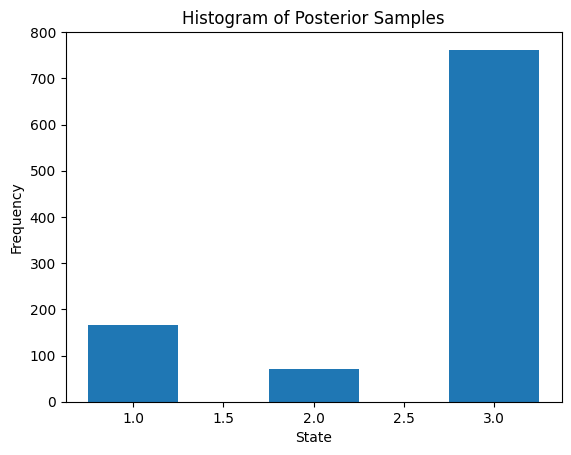

In [ ]:
# Plot histogram of posterior samples
plt.figure()
plt.hist(theta_post, bins=[0.5,1.5,2.5,3.5], rwidth=0.5)
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Histogram of Posterior Samples')
plt.show()

In [ ]:
# Compute proportions
post_counts = pd.Series(theta_post).value_counts().sort_index() / len(theta_post)
warmup_slice = pd.Series(theta_warmup[400:500]).value_counts().sort_index() / 100

# Display results in a table
df = pd.DataFrame({
    'Posterior Proportion': post_counts,
    'Warmup (401–500) Proportion': warmup_slice
})

In [ ]:
df

,Posterior Proportion,Warmup (401–500) Proportion
1,0.167,0.24
2,0.071,0.16
3,0.762,0.60


## b. Convergence with a Different Initial Distribution

Suppose the true stationary distribution (from part (a)) is approximately
$$
\pi \approx (0.186,\;0.094,\;0.720).
$$
You originally started with  
$$
p_1 = (0.1,\;0.7,\;0.2),
$$
but now choose  
$$
p_0 = (0.1,\;0.2,\;0.7).
$$

---

### 1. Total‐Variation Distance

A useful measure of how “far” your start distribution is from stationarity is the **total‐variation (TV) distance**:
$$
\|p - \pi\|_{\rm TV}
= \tfrac12\sum_{i=1}^3 \bigl|p_i - \pi_i\bigr|.
$$

- **Old start** \(p_1\):
  $$
  \|p_1 - \pi\|_{\rm TV}
    = \tfrac12 \bigl(|0.1-0.186| + |0.7-0.094| + |0.2-0.720|\bigr)
    \approx 0.61.
  $$
- **New start** \(p_0\):
  $$
  \|p_0 - \pi\|_{\rm TV}
    = \tfrac12 \bigl(|0.1-0.186| + |0.2-0.094| + |0.7-0.720|\bigr)
    \approx 0.11.
  $$

Because $p_0$ is much closer to $\pi$ in TV‐distance, the chain needs fewer steps to “forget” its starting distribution.

---

### 2. Intuitive Explanation

- **Burn‐in** (“warm‐up”) washes out memory of the start.  
- If you start with most of your mass on state 3—where $\pi$ also concentrates—you’re already near equilibrium.  
- Therefore, **convergence is faster** (shorter burn‐in) when initial mass is placed where the chain spends most of its time.

# 5.2: Metropolis Algorithm

## Metropolis Algorithm

**Goal**: Generate samples from a target distribution $ \pi(\theta) $ using a simple symmetric proposal.

---

### 1. Initialize

1. Choose an initial value  
   $$
     \theta^{(0)} \quad\sim\quad \text{some guess or prior}
   $$
2. Fix the number of iterations $T$ and the proposal scale (step‐size) $\tau$.

---

### 2. For each iteration $t = 1, 2, \dots, T$:

1. **Propose** a candidate  
   $$
     \theta^* \;\sim\; q(\theta^* \mid \theta^{(t-1)})
   $$
   - Common choice: symmetric Normal proposal  
     $$q(\theta^* \mid \theta) = \mathcal{N}(\theta, \tau^2)$$.

2. **Compute** the Metropolis ratio (since $q$ is symmetric, it cancels out):  
   $$
     \alpha
     = \min\!\Biggl\{1,\;
       \frac{\pi(\theta^*)}{\pi(\theta^{(t-1)})}
     \Biggr\}
   $$
   - If your model has likelihood $L(y\mid\theta)$ and prior $p(\theta)$, then  
     $$\displaystyle
       \pi(\theta) \propto L(y\mid\theta)\ p(\theta)
     $$ so  



$$
\alpha
= \min{ }\!\Bigl\{\,1,\;
  \exp\Bigl[
    \log L\bigl(y\mid \theta^*\bigr)
    + \log p\bigl(\theta^*\bigr)
    \;-\;
    \bigl(\log L\bigl(y\mid \theta^{(t-1)}\bigr)
    + \log p\bigl(\theta^{(t-1)}\bigr)\bigr)
  \Bigr]
\Bigr\}.
$$


3. **Accept or reject** the proposal:
   - Draw $u \sim \text{Uniform}(0,1)$.  
   - If $u \le \alpha$, **accept**:  
     $$
       \theta^{(t)} = \theta^*.
     $$
   - Else **reject**:  
     $$
       \theta^{(t)} = \theta^{(t-1)}.
     $$

4. **Store** $\theta^{(t)}$.

---

### 3. Post‐processing

- Discard an initial “burn‐in” period of \(B\) samples to reduce dependence on the starting value.  
- Use the remaining $T - B$ draws to approximate expectations under $\pi$.  
  $$
    \mathbb{E}_{\pi}[f(\theta)] \approx \frac{1}{T-B} \sum_{t=B+1}^T f\bigl(\theta^{(t)}\bigr).
  $$

---

### 4. Pseudocode

```text
Input: initial θ⁰, data y, target π(θ) ∝ L(y|θ) p(θ), proposal scale τ, iterations T
Output: chain {θ⁽ᵗ⁾ : t = 1…T}

for t = 1 to T:
    θ_curr ← θ⁽ᵗ⁻¹⁾
    θ_prop ← Normal(θ_curr, τ²)           # symmetric proposal
    log_ratio ← [logL(y|θ_prop) + log p(θ_prop)]
               − [logL(y|θ_curr) + log p(θ_curr)]
    α ← min(1, exp(log_ratio))
    u ← Uniform(0,1)
    if u ≤ α:
        θ⁽ᵗ⁾ ← θ_prop
    else:
        θ⁽ᵗ⁾ ← θ_curr
    end if
end for

return {θ⁽ᵗ⁾}


In [ ]:
np.random.seed(19)
theta_star = 2.0
sigma = 10.0
N = 200
y = np.random.normal(theta_star, sigma, size=N)

n_chains = 4
iterations = 2000
burn_in = 1000

In [ ]:
def metropolis(y, init, sigma=10.0, iterations=2000, tau=0.5):
    samples = np.empty(iterations)
    samples[0] = init
    for i in range(1, iterations):
        theta_curr = samples[i-1]
        theta_prop = np.random.normal(theta_curr, tau)
        log_like_prop = np.sum(-0.5 * ((y - theta_prop) / sigma)**2 - np.log(sigma) - 0.5*np.log(2*np.pi))
        log_like_curr = np.sum(-0.5 * ((y - theta_curr) / sigma)**2 - np.log(sigma) - 0.5*np.log(2*np.pi))
        alpha = np.exp(log_like_prop - log_like_curr)
        if np.random.rand() < alpha:
            samples[i] = theta_prop
        else:
            samples[i] = theta_curr
    return samples

In [ ]:
# Run 4 chains
chains = []
for i in range(n_chains):
    init_val = np.random.normal()
    chain = metropolis(y, init_val, sigma=sigma, iterations=iterations, tau=0.5)
    chains.append(chain[burn_in:])  # discard first 1000

chains = np.array(chains)  # shape (4, 1000)

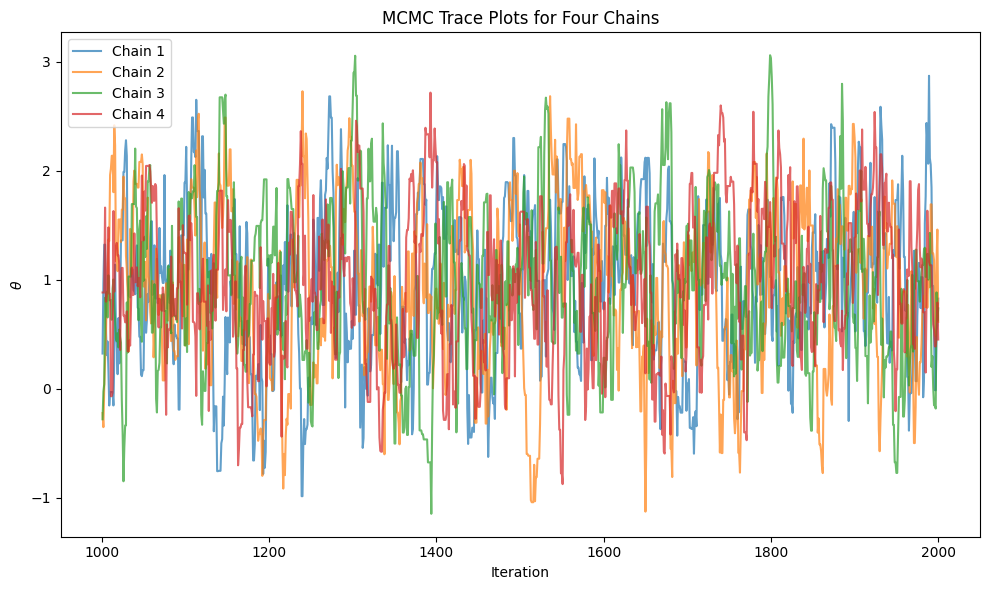

In [ ]:
# Trace plots
plt.figure(figsize=(10, 6))
for idx, chain in enumerate(chains, start=1):
    plt.plot(np.arange(burn_in+1, iterations+1), chain, label=f'Chain {idx}', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel(r'$\theta$')
plt.title('MCMC Trace Plots for Four Chains')
plt.legend()
plt.tight_layout()
plt.show()

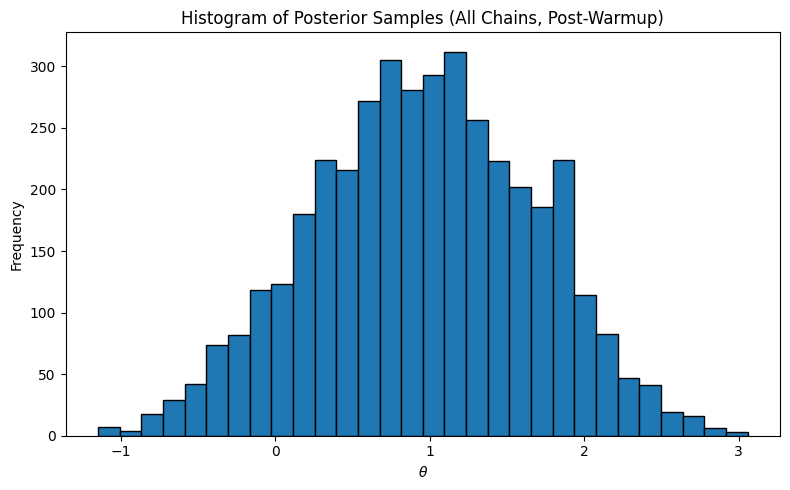

In [ ]:
# Histogram of all post-warmup samples
plt.figure(figsize=(8, 5))
all_samples = chains.flatten()
plt.hist(all_samples, bins=30, edgecolor='black')
plt.xlabel(r'$\theta$')
plt.ylabel('Frequency')
plt.title('Histogram of Posterior Samples (All Chains, Post-Warmup)')
plt.tight_layout()
plt.show()


## 1. Detailed Balance (Reversibility)

A sufficient condition for a Markov chain with transition kernel  
$$
P\bigl(\theta^{(t-1)} \to \theta^*\bigr)
$$
to have $\pi(\theta)$ as its stationary distribution is **detailed balance**:
$$
\pi\bigl(\theta^{(t-1)}\bigr)\,
P\bigl(\theta^{(t-1)} \to \theta^*\bigr)
\;=\;
\pi\bigl(\theta^*\bigr)\,
P\bigl(\theta^* \to \theta^{(t-1)}\bigr).
$$

---

## 2. Decomposing the Transition

In Metropolis–Hastings, each step is split into:

1. **Proposal:**  
   $$
   \theta^* \sim q\bigl(\theta^* \mid \theta^{(t-1)}\bigr).
   $$
2. **Accept/Reject:**  
   With probability $A(\theta^{(t-1)}, \theta^*)$, move to $\theta^*$; otherwise stay at $\theta^{(t-1)}$.

Thus the forward transition probability is  
$$
P\bigl(\theta^{(t-1)} \to \theta^*\bigr)
= q\bigl(\theta^* \mid \theta^{(t-1)}\bigr)\;
  A\bigl(\theta^{(t-1)}, \theta^*\bigr),
$$  
and the reverse is  
$$
P\bigl(\theta^* \to \theta^{(t-1)}\bigr)
= q\bigl(\theta^{(t-1)} \mid \theta^*\bigr)\;
  A\bigl(\theta^*, \theta^{(t-1)}\bigr).
$$

---

## 3. Imposing Detailed Balance

Plug into detailed balance:
$$
\pi(\theta)\,
q(\theta^* \mid \theta)\,
A(\theta, \theta^*)
\;=\;
\pi(\theta^*)\,
q(\theta \mid \theta^*)\,
A(\theta^*, \theta).
$$

We need $0 \le A \le 1$ and this equality to hold. A convenient choice is:

$$
A(\theta, \theta^*)
= \min\!\Bigl\{ 1,\;
  \underbrace{\frac{\pi(\theta^*)}{\pi(\theta)}}_{\displaystyle\text{target ratio}}
  \times
  \underbrace{\frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)}}_{\displaystyle\text{proposal ratio}}
\Bigr\}.
$$

One can verify this satisfies detailed balance exactly.

---

## 4. Special Case: Symmetric Proposals

If the proposal is **symmetric**, i.e.  
$$
q(a \mid b) = q(b \mid a),
$$  
then
$$
\frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)} = 1,
$$  
and the acceptance probability simplifies to the **Metropolis** form:

$$
\alpha
= \min\!\Bigl\{1,\;\frac{\pi(\theta^*)}{\pi(\theta)}\Bigr\}.
$$

---

- **Target ratio** $\displaystyle\frac{\pi(\theta^*)}{\pi(\theta)}$  
  ensures moves favor regions of higher target density.  
- **Proposal ratio** $\displaystyle\frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)}$  
  corrects for any asymmetry in the proposal distribution.  

Together these guarantee that the chain satisfies detailed balance and converges to $\pi(\theta)$ under mild conditions.  
